In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
PHYSICAL_PREDICTORS = ["Wd", "We"]   
TARGET_INT = ["Theta", "X", "Y"]       
TARGET = ["DeltaTheta", "DeltaX", "DeltaY"]       
TIME_STEPS = 3
TS = 0.07
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

Datasets = []
for title in TITLES:
    df = pd.read_excel("../Data/SplinesDatasets.xlsx", sheet_name=title)
    Datasets.append(df)

In [20]:
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    for var in TARGET_INT:
        Dataset[f"Delta{var}"] = (Dataset[var].shift(-1) - Dataset[var]) / TS
    
    Dataset["sPwm"] = Dataset["PwmD"] + Dataset["PwmE"]
    Dataset["dPwm"] = Dataset["PwmD"] - Dataset["PwmE"]

    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET_INT])

    Datasets[i] = Dataset

In [21]:
import matplotlib.pyplot as plt

R = 0.0328
L = 0.0615
dt = 0.07

def CinematicModel(Wd, We, theta):
    dtheta_cin = (R/(2*L)) * (Wd - We)
    dx_cin = (R/2) * np.cos(theta) * (Wd + We)
    dy_cin = (R/2) * np.sin(theta) * (Wd + We)
    return [dtheta_cin, dx_cin, dy_cin]

def NumericalIntegration(Dataset, dq):
    
    init_vals = np.array([
        Dataset["Theta"].iloc[0],
        Dataset["X"].iloc[0],
        Dataset["Y"].iloc[0]
    ]) 
    
    theta_cin = init_vals[0] + np.cumsum(dq[0] * dt)
    x_cin     = init_vals[1] + np.cumsum(dq[1] * dt)
    y_cin     = init_vals[2] + np.cumsum(dq[2] * dt)
    return [theta_cin, x_cin, y_cin]
 
def PlotOut(ax, title, target_name, y_true, y_cin):
    time = (np.arange(0, len(y_cin), 1).astype(float) * 0.07).round(5)

    ax.scatter(time, y_true, marker='o', s=12, label='Amostras Reais', alpha=0.7)
    ax.scatter(time, y_cin, marker='x', s=12, label='Modelo Cinemático', alpha=0.7)
    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)

Processando: Train_1


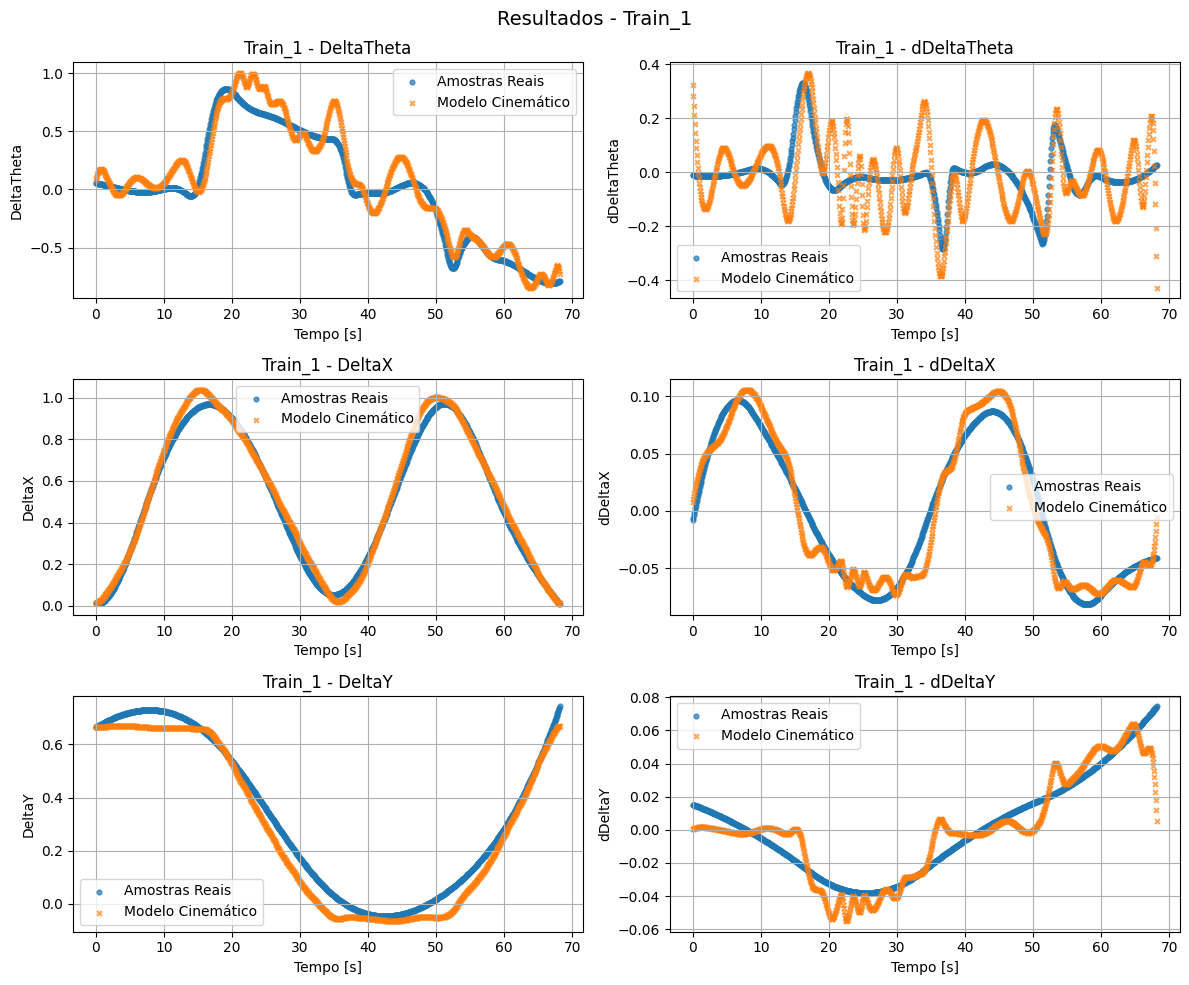

Processando: Train_2


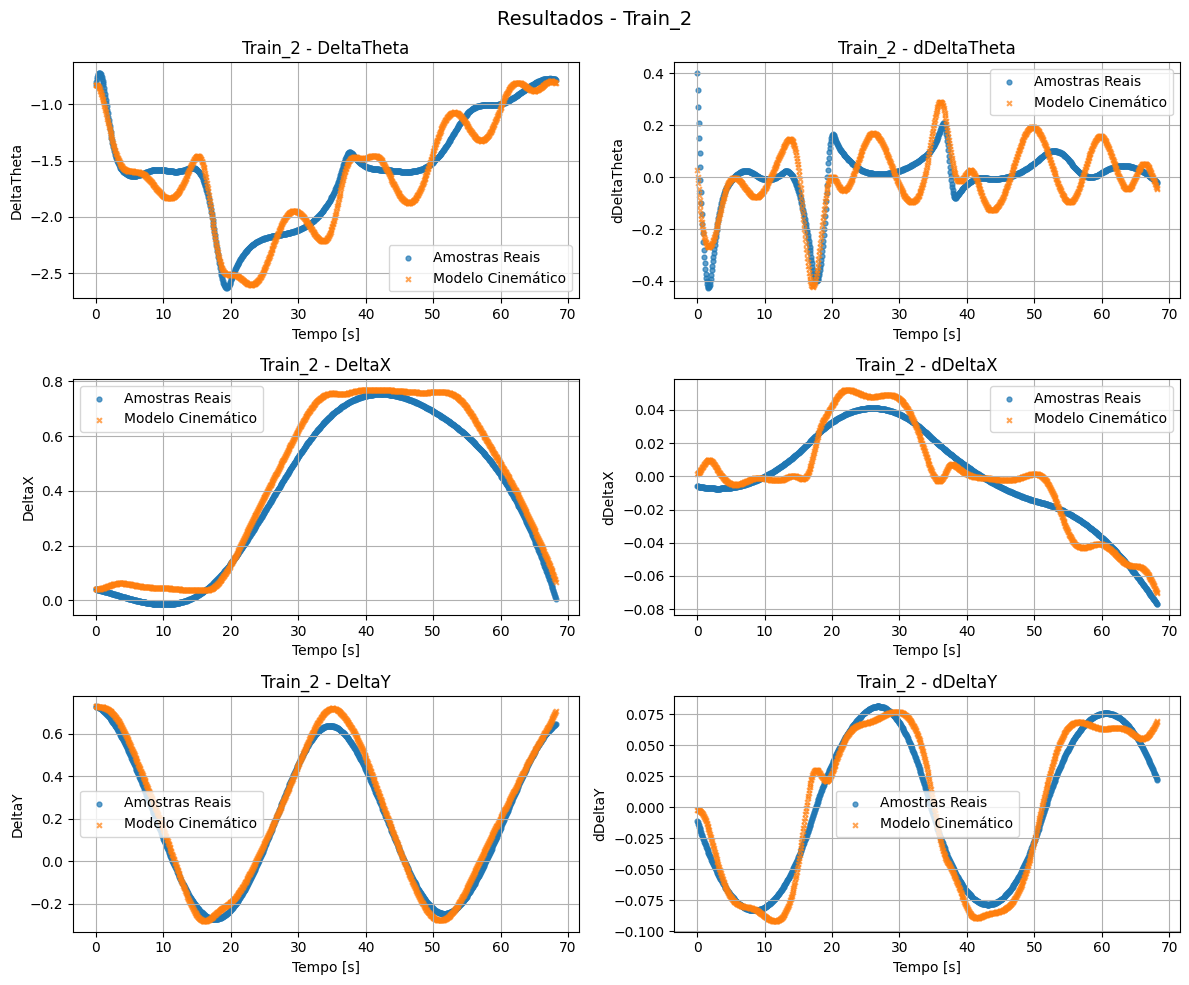

Processando: Test_1


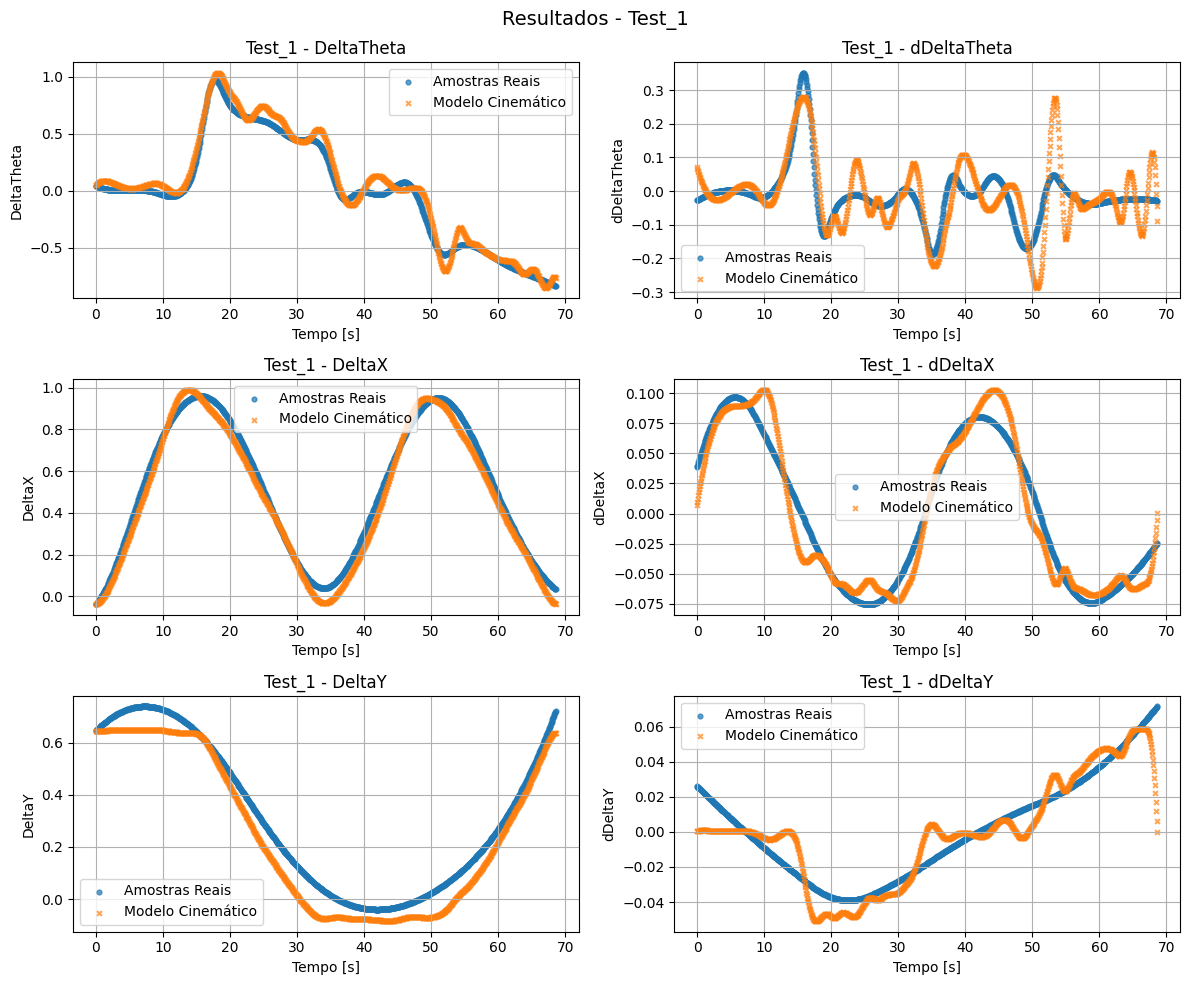

Processando: Test_2


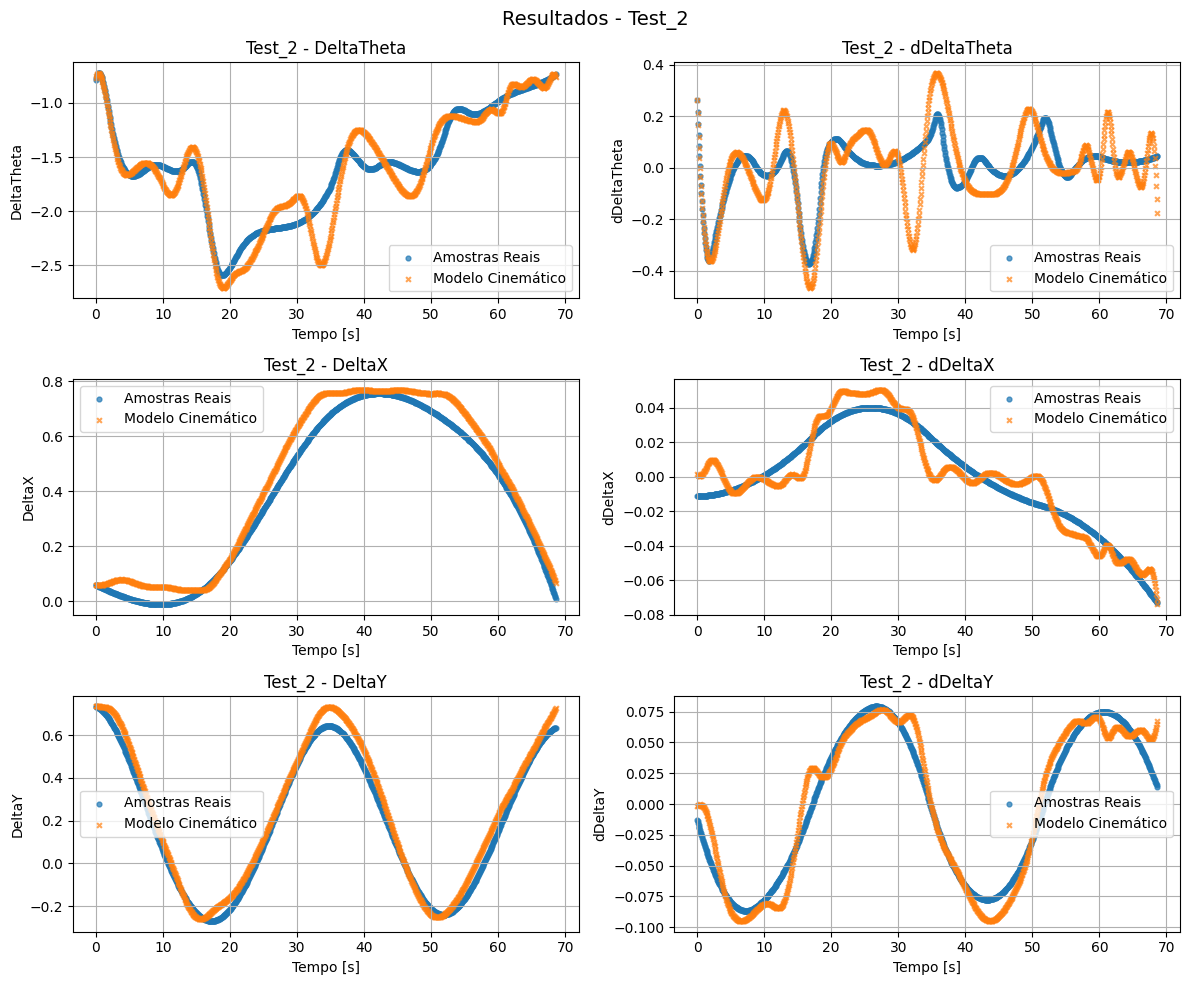

Processando: Test_3


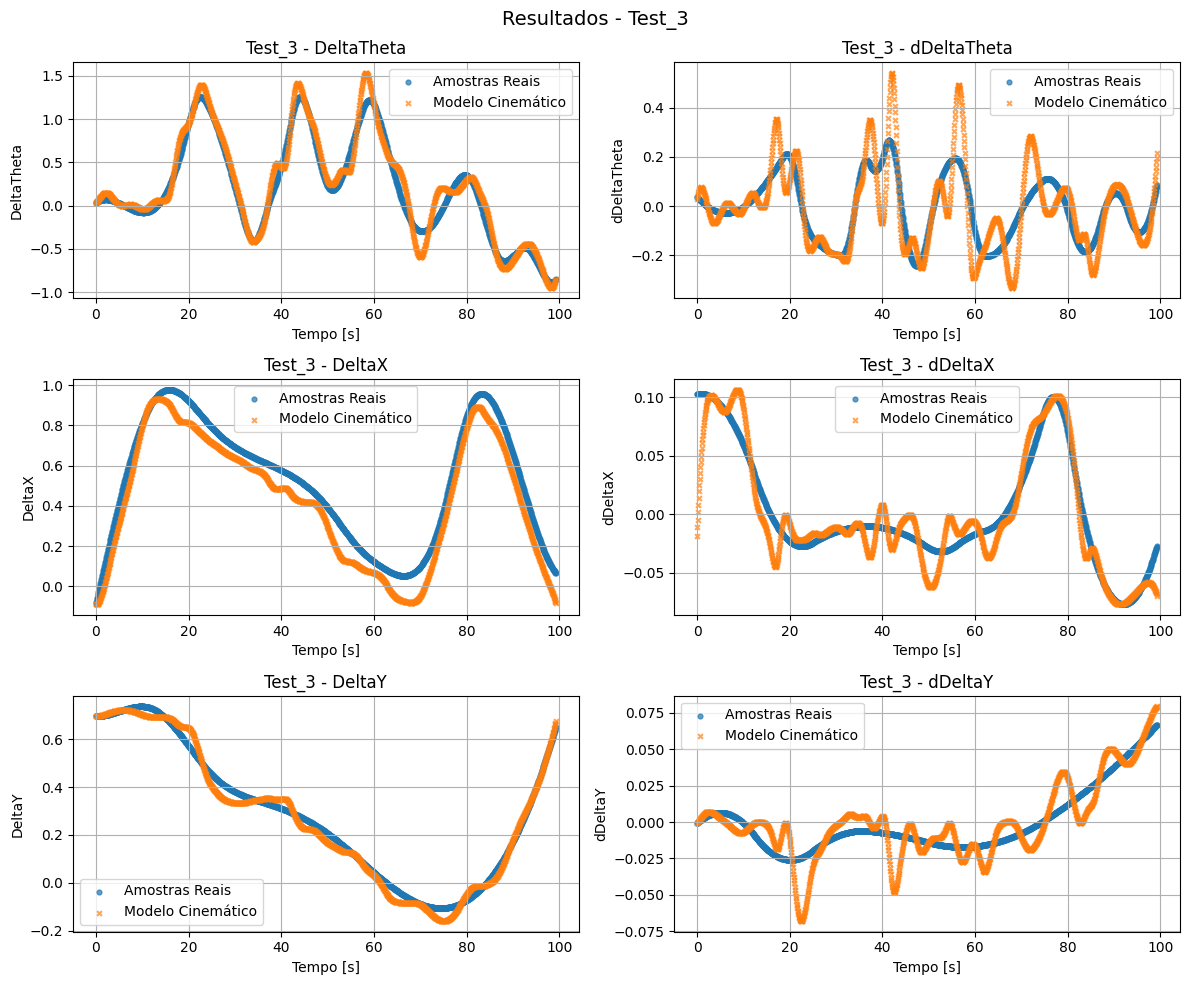

Processando: Val


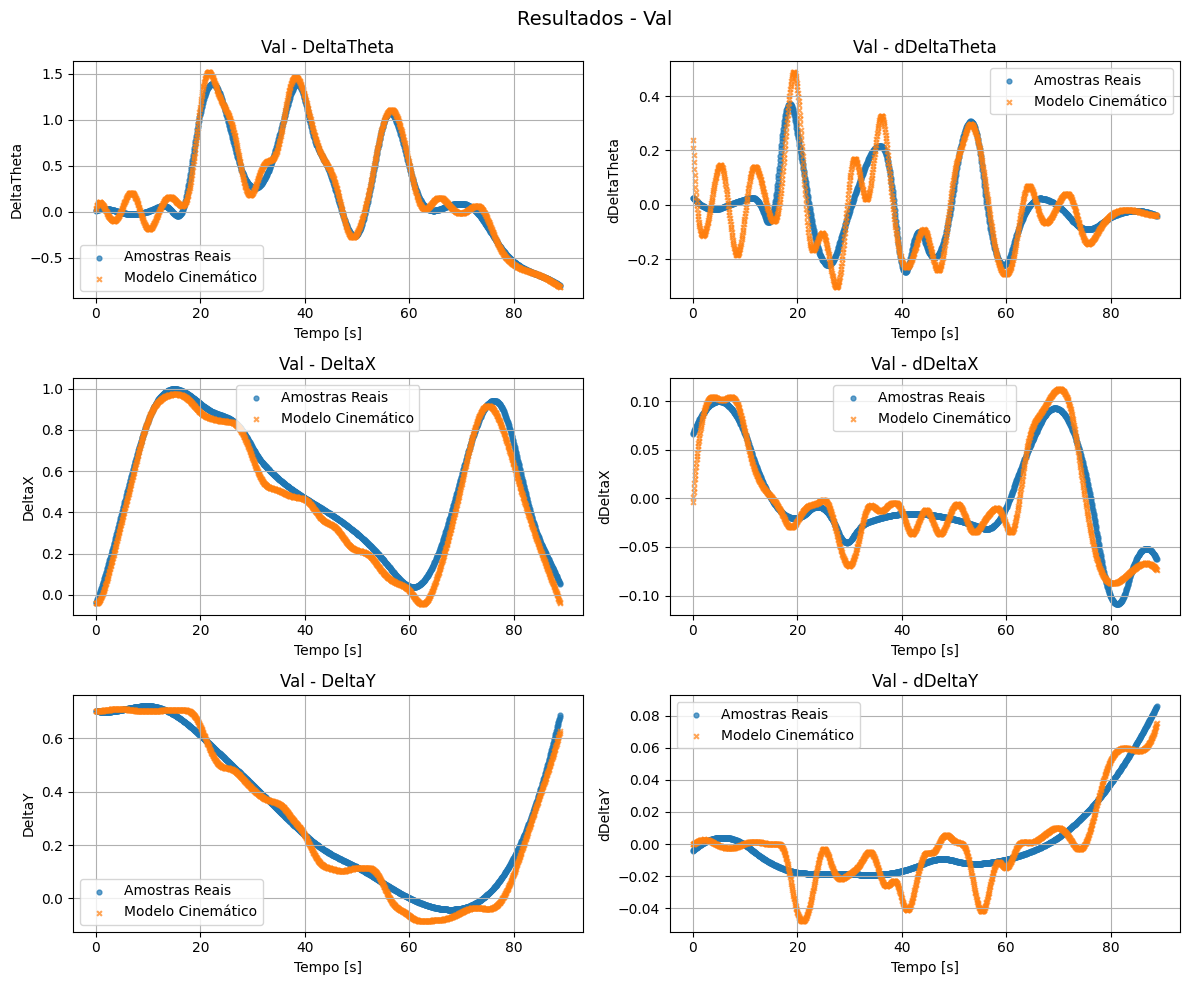

Processando: LSG_1


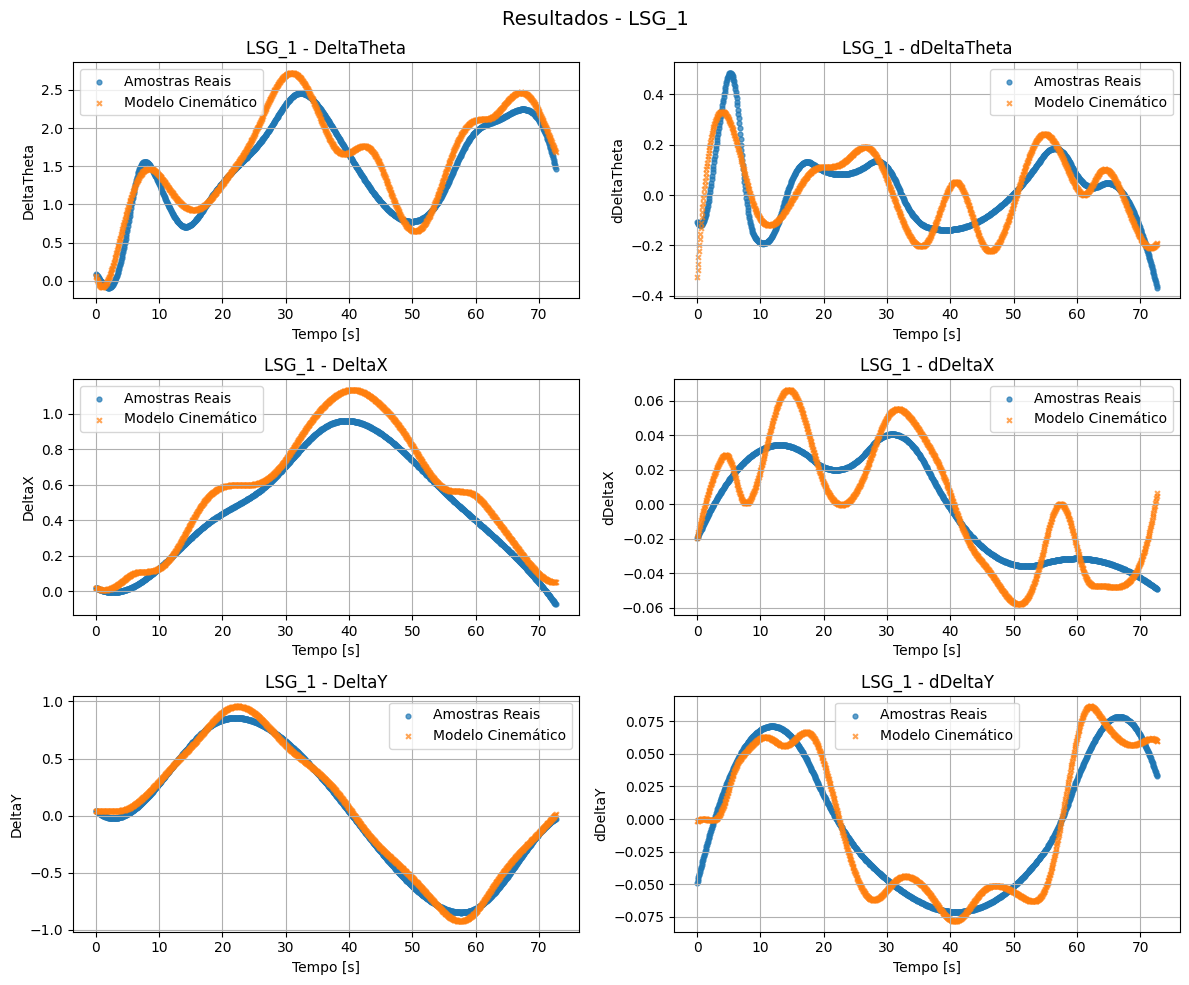

Processando: LSG_2


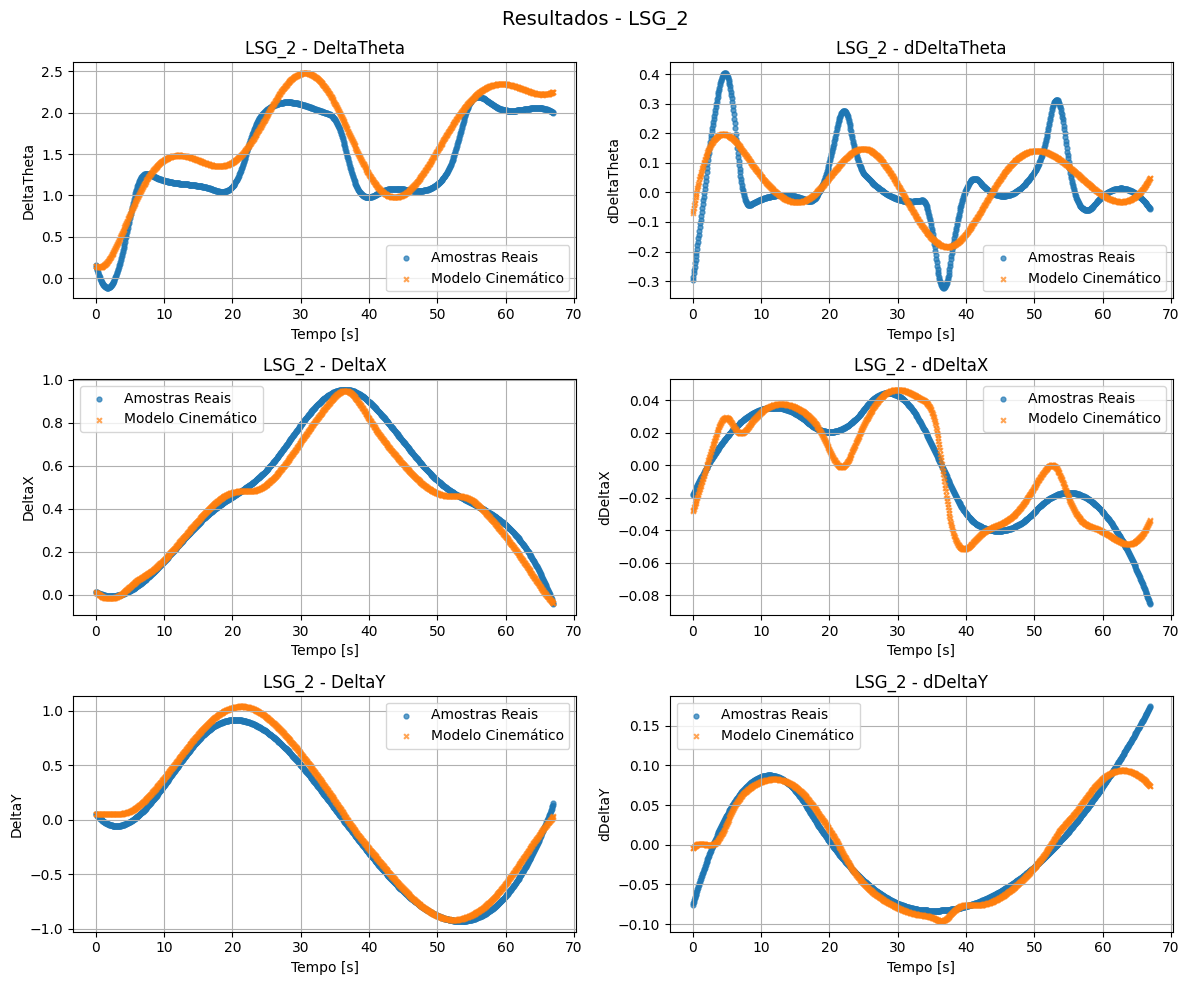

In [29]:
n_targets = len(TARGET)

for title, df in zip(TITLES, Datasets):

    print(f"Processando: {title}")

    # tempo uniforme
    df["tempo"] = np.arange(len(df)) * dt

    # modelo cinemático (derivadas)
    dq = CinematicModel(
        df["Wd"].values,
        df["We"].values,
        df["Theta"].values
    )

    # integração (posição reconstruída)
    q = NumericalIntegration(df, dq)

    # 🔹 matriz de dados
    y_true = np.column_stack([df[t].values for t in TARGET_INT])
    y_cin  = np.column_stack(q)

    dy_cin = np.column_stack(dq)

    # 🔹 derivada "real" (diferença numérica)
    dy_true = np.column_stack([df[t].values for t in TARGET])

    # 🔹 figura: 3 linhas (Theta, X, Y) x 2 colunas (y, dy)
    fig, axs = plt.subplots(n_targets, 2, figsize=(12, 10))
    fig.suptitle(f"Resultados - {title}", fontsize=14)

    for j, name in enumerate(TARGET):

        # 🔹 coluna da posição
        ax_y = axs[j, 0]
        PlotOut(
            ax_y,
            title,
            name,
            y_true[:, j],
            y_cin[:, j]
        )

        # 🔹 coluna da derivada
        ax_dy = axs[j, 1]
        PlotOut(
            ax_dy,
            title,
            f"d{name}",
            dy_true[:, j],
            dy_cin[:, j]
        )

    plt.tight_layout()
    plt.show()

Processando: Train_1


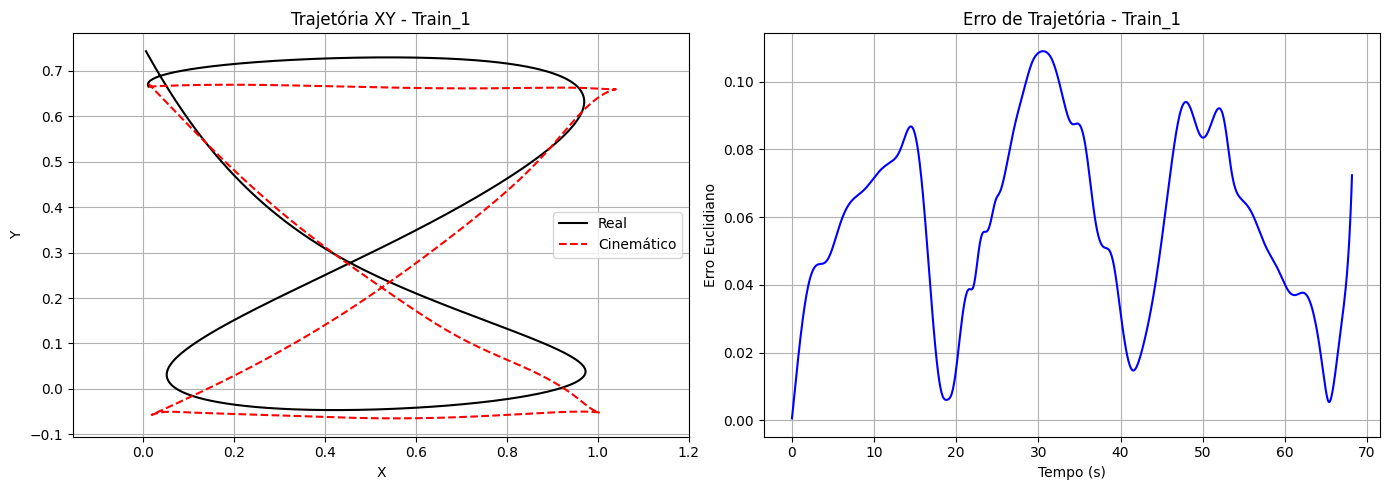

Processando: Train_2


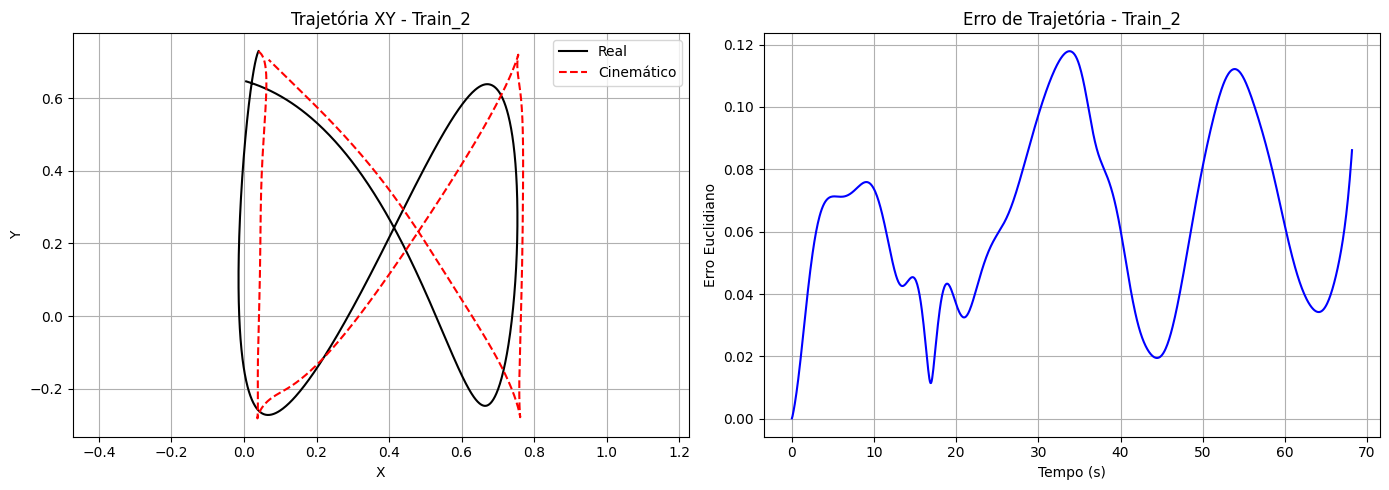

Processando: Test_1


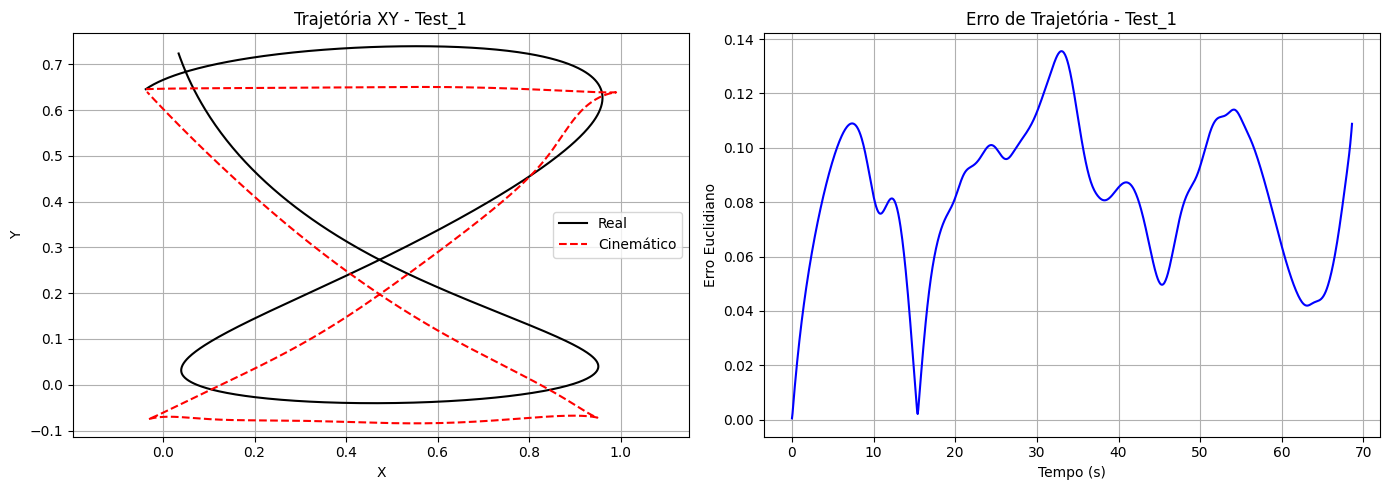

Processando: Test_2


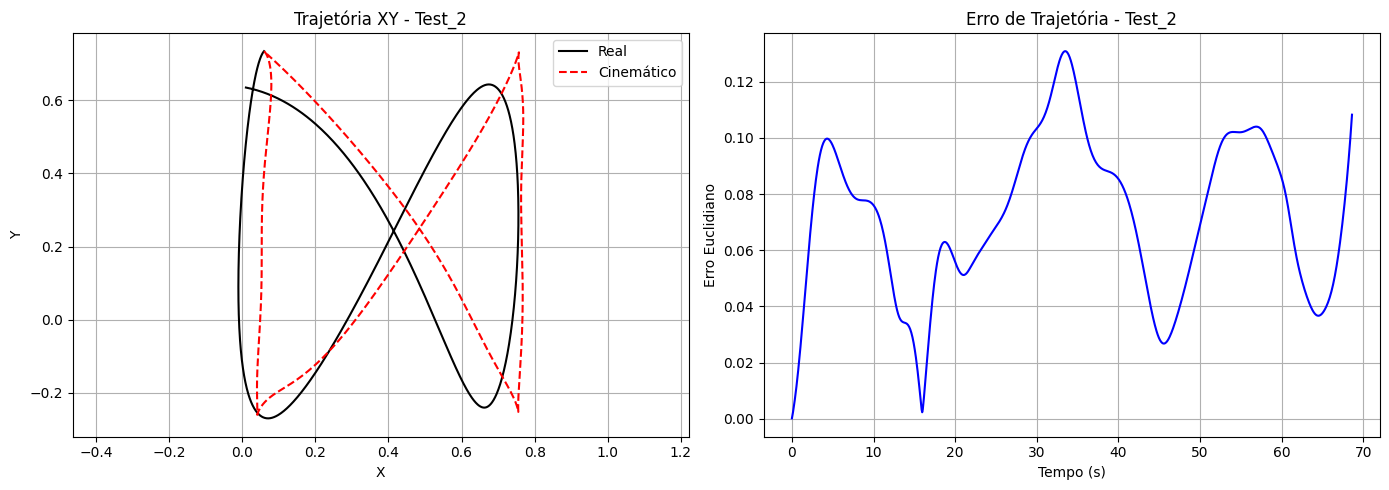

Processando: Test_3


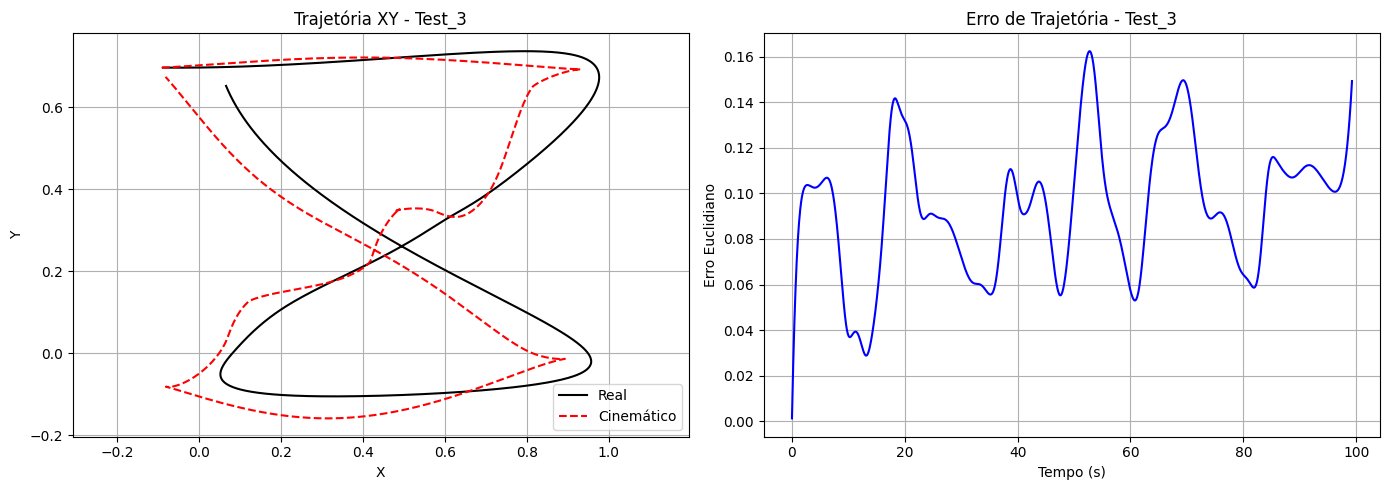

Processando: Val


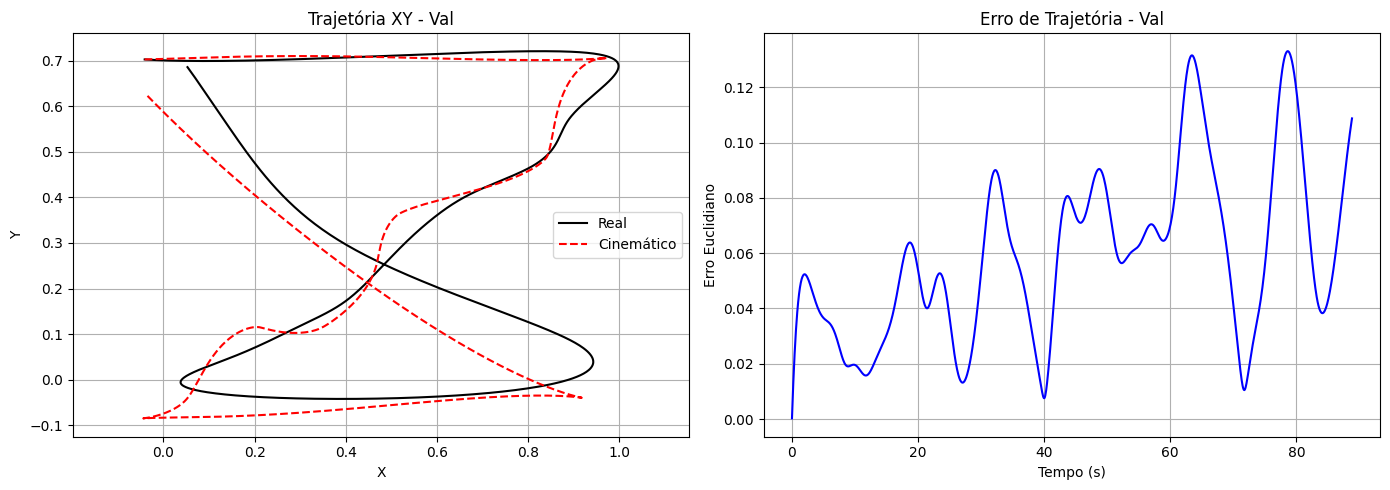

Processando: LSG_1


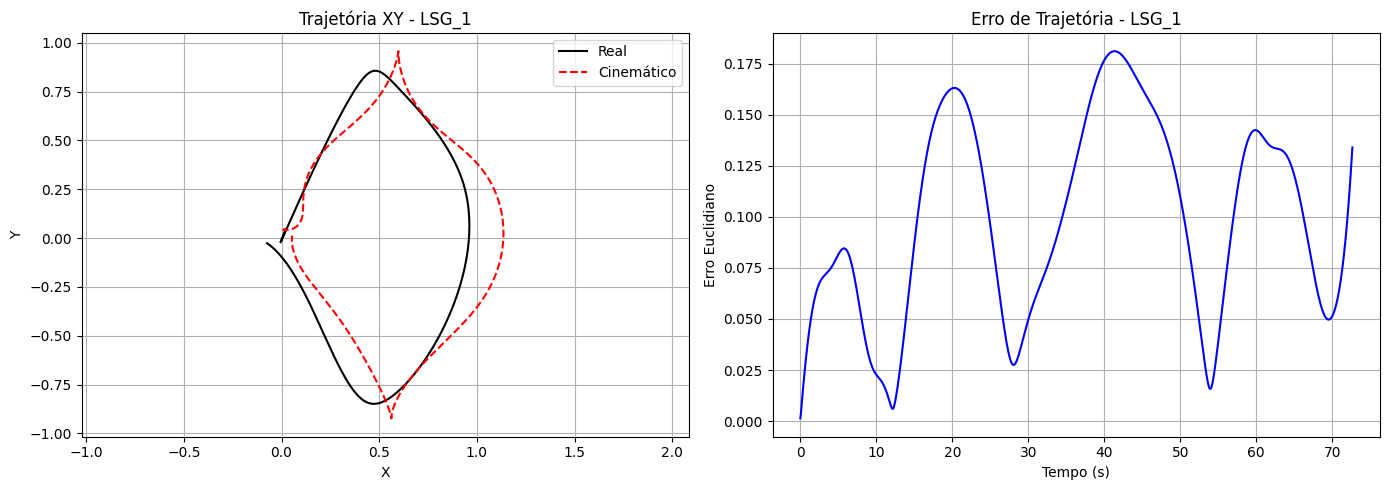

Processando: LSG_2


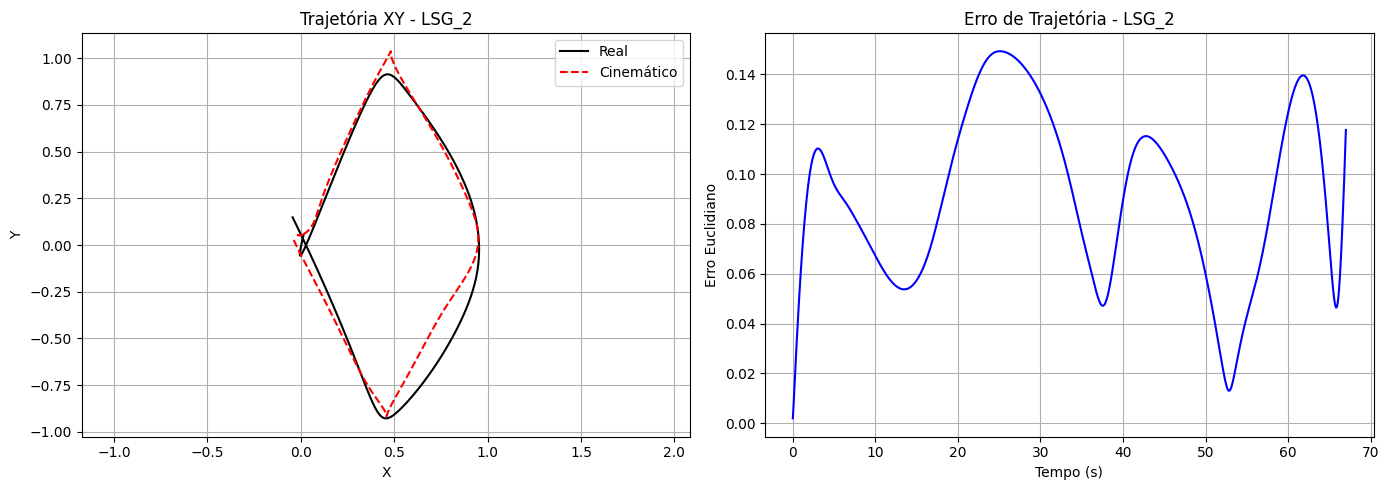

In [ ]:
Ts = 0.07

for title, df in zip(TITLES, Datasets):

    print(f"Processando: {title}")

    # tempo uniforme
    df["tempo"] = np.arange(len(df)) * Ts

    # modelo cinemático
    dq = CinematicModel(
        df["Wd"].values,
        df["We"].values,
        df["Theta"].values
    )

    q = NumericalIntegration(df, dq)

    # 🔹 trajetórias
    X_real = df["X"].values
    Y_real = df["Y"].values

    X_cin = q[1]
    Y_cin = q[2]

    # 🔹 erro ponto a ponto (distância euclidiana)
    erro = np.sqrt((X_real - X_cin)**2 + (Y_real - Y_cin)**2)

    # 🔹 figura
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # =========================
    # 🔹 Trajetória XY
    # =========================
    axs[0].plot(X_real, Y_real, 'k-', label="Real")
    axs[0].plot(X_cin, Y_cin, 'r--', label="Cinemático")

    axs[0].set_title(f"Trajetória XY - {title}")
    axs[0].set_xlabel("X")
    axs[0].set_ylabel("Y")
    axs[0].axis("equal")
    axs[0].grid(True)
    axs[0].legend()

    # =========================
    # 🔹 Erro ao longo do tempo
    # =========================
    axs[1].plot(df["tempo"], erro, 'b-')
    axs[1].set_title(f"Erro de Trajetória - {title}")
    axs[1].set_xlabel("Tempo (s)")
    axs[1].set_ylabel("Erro Euclidiano")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()